In [1]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt


In [2]:
df= pd.read_csv("heart_disease_uci.csv")

In [3]:
df.head()

,id,age,sex,dataset,cp,trestbps,chol,fbs,restecg,thalch,exang,oldpeak,slope,ca,thal,num
0,1,63,Male,Cleveland,typical angina,145.0,233.0,True,lv hypertrophy,150.0,False,2.3,downsloping,0.0,fixed defect,0
1,2,67,Male,Cleveland,asymptomatic,160.0,286.0,False,lv hypertrophy,108.0,True,1.5,flat,3.0,normal,2
2,3,67,Male,Cleveland,asymptomatic,120.0,229.0,False,lv hypertrophy,129.0,True,2.6,flat,2.0,reversable defect,1
3,4,37,Male,Cleveland,non-anginal,130.0,250.0,False,normal,187.0,False,3.5,downsloping,0.0,normal,0
4,5,41,Female,Cleveland,atypical angina,130.0,204.0,False,lv hypertrophy,172.0,False,1.4,upsloping,0.0,normal,0


In [4]:
df["num"].count()

np.int64(920)

In [5]:
df["num"].unique()

array([0, 2, 1, 3, 4])

In [6]:
df.columns

Index(['id', 'age', 'sex', 'dataset', 'cp', 'trestbps', 'chol', 'fbs',
       'restecg', 'thalch', 'exang', 'oldpeak', 'slope', 'ca', 'thal', 'num'],
      dtype='object')

In [7]:
df["age"]

0      63
1      67
2      67
3      37
4      41
       ..
915    54
916    62
917    55
918    58
919    62
Name: age, Length: 920, dtype: int64

In [8]:
filtered_df = df[(df["age"] >= 0) & (df["age"] <= 30)]
filtered_df

,id,age,sex,dataset,cp,trestbps,chol,fbs,restecg,thalch,exang,oldpeak,slope,ca,thal,num
132,133,29,Male,Cleveland,atypical angina,130.0,204.0,False,lv hypertrophy,202.0,False,0.0,upsloping,0.0,normal,0
303,304,28,Male,Cleveland,atypical angina,130.0,132.0,False,lv hypertrophy,185.0,False,0.0,NaN,NaN,NaN,0
304,305,29,Male,Hungary,atypical angina,120.0,243.0,False,normal,160.0,False,0.0,NaN,NaN,NaN,0
305,306,29,Male,Hungary,atypical angina,140.0,NaN,False,normal,170.0,False,0.0,NaN,NaN,NaN,0
306,307,30,Female,Hungary,typical angina,170.0,237.0,False,st-t abnormality,170.0,False,0.0,NaN,NaN,fixed defect,0


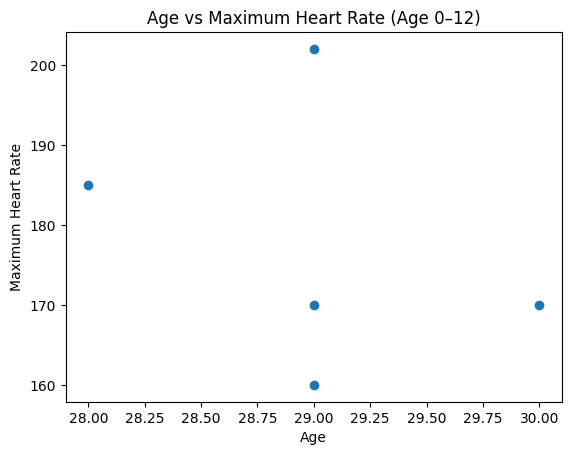

In [9]:
plt.scatter(filtered_df["age"], filtered_df["thalch"])

plt.xlabel("Age")
plt.ylabel("Maximum Heart Rate")
plt.title("Age vs Maximum Heart Rate (Age 0–12)")

plt.show()

In [10]:
df["num"].value_counts()

num
0    411
1    265
2    109
3    107
4     28
Name: count, dtype: int64

In [11]:
df["num"].unique()

array([0, 2, 1, 3, 4])

In [12]:
df["target"] = (df["num"] > 0).astype(int)

In [13]:
df["target"]

0      0
1      1
2      1
3      0
4      0
      ..
915    1
916    0
917    1
918    0
919    1
Name: target, Length: 920, dtype: int64

In [14]:
X = df.drop(columns=["id", "num", "target"])
y = df["target"]

In [15]:
X


,age,sex,dataset,cp,trestbps,chol,fbs,restecg,thalch,exang,oldpeak,slope,ca,thal
0,63,Male,Cleveland,typical angina,145.0,233.0,True,lv hypertrophy,150.0,False,2.3,downsloping,0.0,fixed defect
1,67,Male,Cleveland,asymptomatic,160.0,286.0,False,lv hypertrophy,108.0,True,1.5,flat,3.0,normal
2,67,Male,Cleveland,asymptomatic,120.0,229.0,False,lv hypertrophy,129.0,True,2.6,flat,2.0,reversable defect
3,37,Male,Cleveland,non-anginal,130.0,250.0,False,normal,187.0,False,3.5,downsloping,0.0,normal
4,41,Female,Cleveland,atypical angina,130.0,204.0,False,lv hypertrophy,172.0,False,1.4,upsloping,0.0,normal
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
915,54,Female,VA Long Beach,asymptomatic,127.0,333.0,True,st-t abnormality,154.0,False,0.0,NaN,NaN,NaN
916,62,Male,VA Long Beach,typical angina,NaN,139.0,False,st-t abnormality,NaN,NaN,NaN,NaN,NaN,NaN
917,55,Male,VA Long Beach,asymptomatic,122.0,223.0,True,st-t abnormality,100.0,False,0.0,NaN,NaN,fixed defect
918,58,Male,VA Long Beach,asymptomatic,NaN,385.0,True,lv hypertrophy,NaN,NaN,NaN,NaN,NaN,NaN


In [16]:
y

0      0
1      1
2      1
3      0
4      0
      ..
915    1
916    0
917    1
918    0
919    1
Name: target, Length: 920, dtype: int64

In [17]:
X.isnull().sum()

age           0
sex           0
dataset       0
cp            0
trestbps     59
chol         30
fbs          90
restecg       2
thalch       55
exang        55
oldpeak      62
slope       309
ca          611
thal        486
dtype: int64

In [18]:
df.isnull().sum()

id            0
age           0
sex           0
dataset       0
cp            0
trestbps     59
chol         30
fbs          90
restecg       2
thalch       55
exang        55
oldpeak      62
slope       309
ca          611
thal        486
num           0
target        0
dtype: int64

In [19]:
#Identify numerical  
numeric_features = [
    "age",
    "trestbps",
    "chol",
    "thalch",
    "oldpeak"
]

In [20]:
#categorical columns
categorical_features = [
    "sex",
    "dataset",
    "cp",
    "fbs",
    "restecg",
    "exang",
    "slope",
    "ca",
    "thal"
]

In [21]:
#Train/test split
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

In [22]:
#Handle categorical variables
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder
from sklearn.impute import SimpleImputer
from sklearn.pipeline import Pipeline

In [23]:
#Numerical pipeline:
numeric_pipeline = Pipeline([
    ("imputer", SimpleImputer(strategy="median"))
])

In [24]:
# Categorical pipeline

categorical_pipeline = Pipeline([
    ("imputer", SimpleImputer(strategy="most_frequent")),
    ("encoder", OneHotEncoder(handle_unknown="ignore"))
])

In [25]:
#Combine them:
preprocessor = ColumnTransformer([
    ("num", numeric_pipeline, numeric_features),
    ("cat", categorical_pipeline, categorical_features)
])

In [26]:
from sklearn.linear_model import LogisticRegression

model = Pipeline([
    ("preprocessor", preprocessor),
    ("classifier", LogisticRegression(max_iter=1000))
])

In [27]:
model.fit(X_train, y_train)

/opt/conda/envs/anaconda-2025.12-py312/lib/python3.12/site-packages/sklearn/linear_model/_logistic.py:473: ConvergenceWarning: lbfgs failed to converge after 1000 iteration(s) (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT

Increase the number of iterations to improve the convergence (max_iter=1000).
You might also want to scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


,steps,"[('preprocessor', ...), ('classifier', ...)]"
,transform_input,None
,memory,None
,verbose,False
,transformers,"[('num', ...), ('cat', ...)]"
,remainder,'drop'
,sparse_threshold,0.3
,n_jobs,None
,transformer_weights,None
,verbose,False
,verbose_feature_names_out,True


In [28]:
y_pred = model.predict(X_test)

In [29]:
y_pred

array([0, 1, 1, 1, 1, 1, 0, 1, 0, 1, 0, 0, 0, 0, 1, 1, 0, 1, 0, 1, 1, 1,
       0, 0, 1, 1, 0, 1, 0, 0, 0, 0, 0, 1, 1, 1, 1, 1, 0, 0, 1, 1, 1, 0,
       1, 1, 1, 1, 1, 1, 0, 0, 0, 0, 1, 0, 1, 0, 0, 0, 0, 1, 0, 1, 0, 1,
       1, 1, 0, 0, 1, 1, 0, 1, 0, 1, 1, 0, 1, 1, 0, 1, 1, 0, 1, 0, 1, 1,
       0, 1, 0, 1, 0, 0, 0, 1, 1, 1, 1, 1, 1, 1, 1, 0, 1, 1, 1, 1, 0, 1,
       1, 0, 0, 1, 1, 1, 1, 0, 0, 1, 0, 1, 0, 1, 0, 1, 0, 1, 1, 0, 0, 1,
       0, 0, 1, 1, 0, 0, 1, 1, 1, 1, 0, 0, 1, 1, 1, 0, 0, 1, 1, 0, 1, 1,
       1, 1, 0, 1, 1, 0, 0, 1, 1, 0, 1, 1, 1, 1, 0, 1, 1, 0, 1, 1, 0, 0,
       0, 0, 1, 1, 1, 1, 1, 1])

In [30]:
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    classification_report
)

print("Accuracy:", accuracy_score(y_test, y_pred))
print("Precision:", precision_score(y_test, y_pred))
print("Recall:", recall_score(y_test, y_pred))
print("F1:", f1_score(y_test, y_pred))

Accuracy: 0.842391304347826
Precision: 0.8348623853211009
Recall: 0.8921568627450981
F1: 0.8625592417061612


In [31]:
y_prob = model.predict_proba(X_test)[:, 1]

print("ROC-AUC:", roc_auc_score(y_test, y_prob))

ROC-AUC: 0.925872788139646


In [32]:
print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       0.85      0.78      0.82        82
           1       0.83      0.89      0.86       102

    accuracy                           0.84       184
   macro avg       0.84      0.84      0.84       184
weighted avg       0.84      0.84      0.84       184



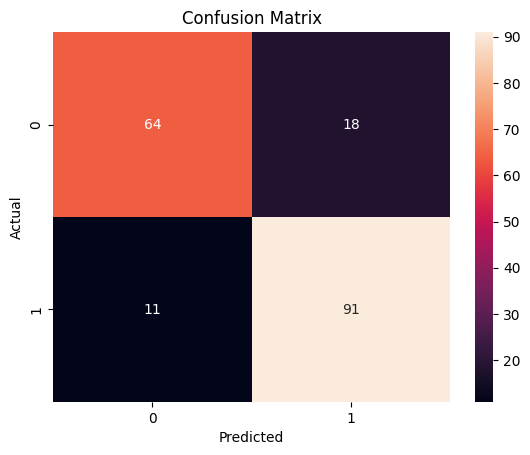

In [33]:
from sklearn.metrics import confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

cm = confusion_matrix(y_test, y_pred)

sns.heatmap(cm, annot=True, fmt="d")

plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix")

plt.show()

In [34]:
print(df.shape)
print(df["num"].value_counts())
print(df.isnull().sum())

(920, 17)
num
0    411
1    265
2    109
3    107
4     28
Name: count, dtype: int64
id            0
age           0
sex           0
dataset       0
cp            0
trestbps     59
chol         30
fbs          90
restecg       2
thalch       55
exang        55
oldpeak      62
slope       309
ca          611
thal        486
num           0
target        0
dtype: int64


In [35]:
X.dtypes

age           int64
sex          object
dataset      object
cp           object
trestbps    float64
chol        float64
fbs          object
restecg      object
thalch      float64
exang        object
oldpeak     float64
slope        object
ca          float64
thal         object
dtype: object

In [36]:
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import OneHotEncoder
from sklearn.compose import ColumnTransformer

numeric_pipeline = Pipeline([
    ("imputer", SimpleImputer(strategy="median"))
])

categorical_pipeline = Pipeline([
    ("imputer", SimpleImputer(strategy="most_frequent")),
    ("encoder", OneHotEncoder(handle_unknown="ignore"))
])

preprocessor = ColumnTransformer([
    ("num", numeric_pipeline, numeric_features),
    ("cat", categorical_pipeline, categorical_features)
])

In [37]:
from sklearn.linear_model import LogisticRegression

model = Pipeline([
    ("preprocessor", preprocessor),
    ("classifier", LogisticRegression(max_iter=2000))
])

In [38]:
model.fit(X_train, y_train)

,steps,"[('preprocessor', ...), ('classifier', ...)]"
,transform_input,None
,memory,None
,verbose,False
,transformers,"[('num', ...), ('cat', ...)]"
,remainder,'drop'
,sparse_threshold,0.3
,n_jobs,None
,transformer_weights,None
,verbose,False
,verbose_feature_names_out,True


In [39]:
y_pred = model.predict(X_test)

In [40]:
model.fit(X_train, y_train)

y_pred = model.predict(X_test)

print(y_pred[:20])

[0 1 1 1 1 1 0 1 0 1 0 0 0 0 1 1 0 1 0 1]


In [41]:
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    classification_report
)

print("Accuracy:", accuracy_score(y_test, y_pred))
print("Precision:", precision_score(y_test, y_pred))
print("Recall:", recall_score(y_test, y_pred))
print("F1:", f1_score(y_test, y_pred))

y_prob = model.predict_proba(X_test)[:, 1]

print("ROC-AUC:", roc_auc_score(y_test, y_prob))

print(classification_report(y_test, y_pred))

Accuracy: 0.842391304347826
Precision: 0.8348623853211009
Recall: 0.8921568627450981
F1: 0.8625592417061612
ROC-AUC: 0.9252749880439981
              precision    recall  f1-score   support

           0       0.85      0.78      0.82        82
           1       0.83      0.89      0.86       102

    accuracy                           0.84       184
   macro avg       0.84      0.84      0.84       184
weighted avg       0.84      0.84      0.84       184



In [42]:
from sklearn.ensemble import RandomForestClassifier

In [43]:
rf_model = Pipeline([
    ("preprocessor", preprocessor),
    ("classifier", RandomForestClassifier(
        n_estimators=200,
        random_state=42,
        class_weight="balanced"
    ))
])

In [44]:
rf_model.fit(X_train, y_train)

,steps,"[('preprocessor', ...), ('classifier', ...)]"
,transform_input,None
,memory,None
,verbose,False
,transformers,"[('num', ...), ('cat', ...)]"
,remainder,'drop'
,sparse_threshold,0.3
,n_jobs,None
,transformer_weights,None
,verbose,False
,verbose_feature_names_out,True


In [45]:
rf_pred = rf_model.predict(X_test)
rf_prob = rf_model.predict_proba(X_test)[:, 1]

In [46]:
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    classification_report
)

print("Accuracy:", accuracy_score(y_test, rf_pred))
print("Precision:", precision_score(y_test, rf_pred))
print("Recall:", recall_score(y_test, rf_pred))
print("F1:", f1_score(y_test, rf_pred))
print("ROC-AUC:", roc_auc_score(y_test, rf_prob))

print("\nClassification Report:")
print(classification_report(y_test, rf_pred))

Accuracy: 0.8478260869565217
Precision: 0.8425925925925926
Recall: 0.8921568627450981
F1: 0.8666666666666667
ROC-AUC: 0.9283835485413678

Classification Report:
              precision    recall  f1-score   support

           0       0.86      0.79      0.82        82
           1       0.84      0.89      0.87       102

    accuracy                           0.85       184
   macro avg       0.85      0.84      0.84       184
weighted avg       0.85      0.85      0.85       184



[[65 17]
 [11 91]]


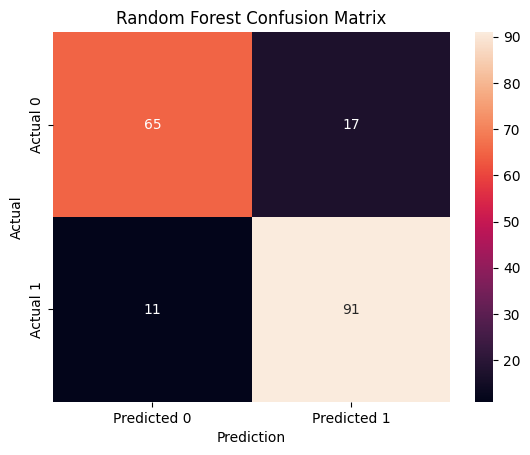

In [47]:
from sklearn.metrics import confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

cm = confusion_matrix(y_test, rf_pred)

print(cm)

sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    xticklabels=["Predicted 0", "Predicted 1"],
    yticklabels=["Actual 0", "Actual 1"]
)

plt.xlabel("Prediction")
plt.ylabel("Actual")
plt.title("Random Forest Confusion Matrix")
plt.show()

In [48]:
from xgboost import XGBClassifier

/home/c2d7bc1b-d73a-414e-bd72-b357fd4620b7/.local/lib/python3.12/site-packages/xgboost/compat.py:105: UserWarning: pkg_resources is deprecated as an API. See https://setuptools.pypa.io/en/latest/pkg_resources.html. The pkg_resources package is slated for removal as early as 2025-11-30. Refrain from using this package or pin to Setuptools<81.
  import pkg_resources


In [49]:
xgb_model = Pipeline([
    ("preprocessor", preprocessor),
    ("classifier", XGBClassifier(
        n_estimators=200,
        max_depth=4,
        learning_rate=0.05,
        random_state=42,
        eval_metric="logloss"
    ))
])

In [50]:
xgb_model.fit(X_train, y_train)

,steps,"[('preprocessor', ...), ('classifier', ...)]"
,transform_input,None
,memory,None
,verbose,False
,transformers,"[('num', ...), ('cat', ...)]"
,remainder,'drop'
,sparse_threshold,0.3
,n_jobs,None
,transformer_weights,None
,verbose,False
,verbose_feature_names_out,True


In [51]:
xgb_pred = xgb_model.predict(X_test)
xgb_prob = xgb_model.predict_proba(X_test)[:, 1]

In [52]:
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    classification_report
)

print("Accuracy:", accuracy_score(y_test, xgb_pred))
print("Precision:", precision_score(y_test, xgb_pred))
print("Recall:", recall_score(y_test, xgb_pred))
print("F1:", f1_score(y_test, xgb_pred))
print("ROC-AUC:", roc_auc_score(y_test, xgb_prob))

print("\nClassification Report:")
print(classification_report(y_test, xgb_pred))

Accuracy: 0.8478260869565217
Precision: 0.8490566037735849
Recall: 0.8823529411764706
F1: 0.8653846153846154
ROC-AUC: 0.916547106647537

Classification Report:
              precision    recall  f1-score   support

           0       0.85      0.80      0.82        82
           1       0.85      0.88      0.87       102

    accuracy                           0.85       184
   macro avg       0.85      0.84      0.85       184
weighted avg       0.85      0.85      0.85       184



In [53]:
#Model comparison
# Model	Accuracy	Precision	Recall	F1	ROC-AUC
# Logistic Regression	84.2%	83.5%	89.2%	86.3%	92.5%
# Random Forest	84.8%	84.3%	89.2%	86.7%	92.8%
# XGBoost	84.8%	84.9%	88.2%	86.5%	91.7%

In [54]:
from sklearn.model_selection import StratifiedKFold, cross_val_score

cv = StratifiedKFold(
    n_splits=5,
    shuffle=True,
    random_state=42
)

rf_cv_scores = cross_val_score(
    rf_model,
    X,
    y,
    cv=cv,
    scoring="roc_auc"
)

print("ROC-AUC scores:", rf_cv_scores)
print("Mean ROC-AUC:", rf_cv_scores.mean())
print("Std ROC-AUC:", rf_cv_scores.std())

ROC-AUC scores: [0.90462841 0.90746055 0.87123386 0.86579388 0.90512912]
Mean ROC-AUC: 0.8908491645174959
Std ROC-AUC: 0.018342576260851062


In [55]:
lr_cv_scores = cross_val_score(
    model,
    X,
    y,
    cv=cv,
    scoring="roc_auc"
)

xgb_cv_scores = cross_val_score(
    xgb_model,
    X,
    y,
    cv=cv,
    scoring="roc_auc"
)

print("Logistic Regression:", lr_cv_scores.mean(), "+/-", lr_cv_scores.std())
print("Random Forest:", rf_cv_scores.mean(), "+/-", rf_cv_scores.std())
print("XGBoost:", xgb_cv_scores.mean(), "+/-", xgb_cv_scores.std())

/opt/conda/envs/anaconda-2025.12-py312/lib/python3.12/site-packages/sklearn/model_selection/_validation.py:971: UserWarning: Scoring failed. The score on this train-test partition for these parameters will be set to nan. Details: 
Traceback (most recent call last):
  File "/opt/conda/envs/anaconda-2025.12-py312/lib/python3.12/site-packages/sklearn/metrics/_scorer.py", line 152, in __call__
    score = scorer._score(
            ^^^^^^^^^^^^^^
  File "/opt/conda/envs/anaconda-2025.12-py312/lib/python3.12/site-packages/sklearn/metrics/_scorer.py", line 400, in _score
    y_pred = method_caller(
             ^^^^^^^^^^^^^^
  File "/opt/conda/envs/anaconda-2025.12-py312/lib/python3.12/site-packages/sklearn/metrics/_scorer.py", line 90, in _cached_call
    result, _ = _get_response_values(
                ^^^^^^^^^^^^^^^^^^^^^
  File "/opt/conda/envs/anaconda-2025.12-py312/lib/python3.12/site-packages/sklearn/utils/_response.py", line 235, in _get_response_values
    raise ValueError(
Value

Logistic Regression: 0.9063490805701889 +/- 0.017864048103629647
Random Forest: 0.8908491645174959 +/- 0.018342576260851062
XGBoost: nan +/- nan


/opt/conda/envs/anaconda-2025.12-py312/lib/python3.12/site-packages/sklearn/model_selection/_validation.py:971: UserWarning: Scoring failed. The score on this train-test partition for these parameters will be set to nan. Details: 
Traceback (most recent call last):
  File "/opt/conda/envs/anaconda-2025.12-py312/lib/python3.12/site-packages/sklearn/metrics/_scorer.py", line 152, in __call__
    score = scorer._score(
            ^^^^^^^^^^^^^^
  File "/opt/conda/envs/anaconda-2025.12-py312/lib/python3.12/site-packages/sklearn/metrics/_scorer.py", line 400, in _score
    y_pred = method_caller(
             ^^^^^^^^^^^^^^
  File "/opt/conda/envs/anaconda-2025.12-py312/lib/python3.12/site-packages/sklearn/metrics/_scorer.py", line 90, in _cached_call
    result, _ = _get_response_values(
                ^^^^^^^^^^^^^^^^^^^^^
  File "/opt/conda/envs/anaconda-2025.12-py312/lib/python3.12/site-packages/sklearn/utils/_response.py", line 235, in _get_response_values
    raise ValueError(
Value

In [56]:
import sklearn
import xgboost
from sklearn.base import is_classifier

print("scikit-learn:", sklearn.__version__)
print("xgboost:", xgboost.__version__)

xgb_test = XGBClassifier()

print(is_classifier(xgb_test))

scikit-learn: 1.7.2
xgboost: 1.6.2
False


In [57]:
%pip install -U xgboost

Defaulting to user installation because normal site-packages is not writeable
Looking in links: /usr/share/pip-wheels
  Using cached xgboost-3.4.1-py3-none-manylinux_2_28_x86_64.whl.metadata (2.0 kB)
  Using cached nvidia_nccl_cu13-2.31.2-py3-none-manylinux_2_18_x86_64.whl.metadata (2.1 kB)
Using cached xgboost-3.4.1-py3-none-manylinux_2_28_x86_64.whl (57.6 MB)
Using cached nvidia_nccl_cu13-2.31.2-py3-none-manylinux_2_18_x86_64.whl (252.4 MB)
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 0/2 [nvidia-nccl-cu13]ERROR: Could not install packages due to an OSError: [Errno 122] Disk quota exceeded

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 0/2 [nvidia-nccl-cu13]
Note: you may need to restart the kernel to use updated packages.


In [68]:
import sklearn
import xgboost
from xgboost import XGBClassifier
from sklearn.base import is_classifier

print("scikit-learn:", sklearn.__version__)
print("xgboost:", xgboost.__version__)

model_test = XGBClassifier()
print("is_classifier:", is_classifier(model_test))

scikit-learn: 1.7.2
xgboost: 1.6.2
is_classifier: False


In [69]:
import sys
print(sys.executable)

%pip show xgboost

/opt/conda/envs/anaconda-2025.12-py312/bin/python
Name: xgboost
Version: 1.6.2
Summary: XGBoost Python Package
Home-page: https://github.com/dmlc/xgboost
Author: 
Author-email: 
License: Apache-2.0
Location: /home/c2d7bc1b-d73a-414e-bd72-b357fd4620b7/.local/lib/python3.12/site-packages
Requires: numpy, scipy
Required-by: autoviz
Note: you may need to restart the kernel to use updated packages.


In [70]:
import sys

!{sys.executable} -m pip install --upgrade --user xgboost

Looking in links: /usr/share/pip-wheels
  Using cached xgboost-3.4.1-py3-none-manylinux_2_28_x86_64.whl.metadata (2.0 kB)
  Using cached nvidia_nccl_cu13-2.31.2-py3-none-manylinux_2_18_x86_64.whl.metadata (2.1 kB)
Using cached xgboost-3.4.1-py3-none-manylinux_2_28_x86_64.whl (57.6 MB)
Using cached nvidia_nccl_cu13-2.31.2-py3-none-manylinux_2_18_x86_64.whl (252.4 MB)
ERROR: Could not install packages due to an OSError: [Errno 122] Disk quota exceeded

You can safely remove it manually.


In [72]:
from xgboost import XGBClassifier

xgb = XGBClassifier(
    random_state=42,
    eval_metric="logloss"
)

In [73]:
param_dist = {
    "n_estimators": [100, 200, 300, 500],
    "max_depth": [3, 4, 5, 6, 8],
    "learning_rate": [0.01, 0.05, 0.1, 0.2],
    "subsample": [0.7, 0.8, 0.9, 1.0],
    "colsample_bytree": [0.7, 0.8, 0.9, 1.0],
    "min_child_weight": [1, 3, 5, 7],
    "gamma": [0, 0.1, 0.3, 0.5]
}

In [74]:
from sklearn.model_selection import RandomizedSearchCV

random_search = RandomizedSearchCV(
    estimator=xgb,
    param_distributions=param_dist,
    n_iter=30,
    scoring="roc_auc",
    cv=5,
    random_state=42,
    n_jobs=-1,
    verbose=1)

In [75]:
random_search.fit(X_train, y_train)

Fitting 5 folds for each of 30 candidates, totalling 150 fits


/opt/conda/envs/anaconda-2025.12-py312/lib/python3.12/multiprocessing/queues.py:122: UserWarning: pkg_resources is deprecated as an API. See https://setuptools.pypa.io/en/latest/pkg_resources.html. The pkg_resources package is slated for removal as early as 2025-11-30. Refrain from using this package or pin to Setuptools<81.
  return _ForkingPickler.loads(res)
/opt/conda/envs/anaconda-2025.12-py312/lib/python3.12/multiprocessing/queues.py:122: UserWarning: pkg_resources is deprecated as an API. See https://setuptools.pypa.io/en/latest/pkg_resources.html. The pkg_resources package is slated for removal as early as 2025-11-30. Refrain from using this package or pin to Setuptools<81.
  return _ForkingPickler.loads(res)
/opt/conda/envs/anaconda-2025.12-py312/lib/python3.12/multiprocessing/queues.py:122: UserWarning: pkg_resources is deprecated as an API. See https://setuptools.pypa.io/en/latest/pkg_resources.html. The pkg_resources package is slated for removal as early as 2025-11-30. Refr

ValueError: 
All the 150 fits failed.
It is very likely that your model is misconfigured.
You can try to debug the error by setting error_score='raise'.

Below are more details about the failures:
--------------------------------------------------------------------------------
150 fits failed with the following error:
Traceback (most recent call last):
  File "/opt/conda/envs/anaconda-2025.12-py312/lib/python3.12/site-packages/sklearn/model_selection/_validation.py", line 859, in _fit_and_score
    estimator.fit(X_train, y_train, **fit_params)
  File "/home/c2d7bc1b-d73a-414e-bd72-b357fd4620b7/.local/lib/python3.12/site-packages/xgboost/core.py", line 575, in inner_f
    return f(**kwargs)
           ^^^^^^^^^^^
  File "/home/c2d7bc1b-d73a-414e-bd72-b357fd4620b7/.local/lib/python3.12/site-packages/xgboost/sklearn.py", line 1382, in fit
    train_dmatrix, evals = _wrap_evaluation_matrices(
                           ^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "/home/c2d7bc1b-d73a-414e-bd72-b357fd4620b7/.local/lib/python3.12/site-packages/xgboost/sklearn.py", line 401, in _wrap_evaluation_matrices
    train_dmatrix = create_dmatrix(
                    ^^^^^^^^^^^^^^^
  File "/home/c2d7bc1b-d73a-414e-bd72-b357fd4620b7/.local/lib/python3.12/site-packages/xgboost/sklearn.py", line 1396, in <lambda>
    create_dmatrix=lambda **kwargs: DMatrix(nthread=self.n_jobs, **kwargs),
                                    ^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "/home/c2d7bc1b-d73a-414e-bd72-b357fd4620b7/.local/lib/python3.12/site-packages/xgboost/core.py", line 575, in inner_f
    return f(**kwargs)
           ^^^^^^^^^^^
  File "/home/c2d7bc1b-d73a-414e-bd72-b357fd4620b7/.local/lib/python3.12/site-packages/xgboost/core.py", line 686, in __init__
    handle, feature_names, feature_types = dispatch_data_backend(
                                           ^^^^^^^^^^^^^^^^^^^^^^
  File "/home/c2d7bc1b-d73a-414e-bd72-b357fd4620b7/.local/lib/python3.12/site-packages/xgboost/data.py", line 889, in dispatch_data_backend
    return _from_pandas_df(data, enable_categorical, missing, threads,
           ^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "/home/c2d7bc1b-d73a-414e-bd72-b357fd4620b7/.local/lib/python3.12/site-packages/xgboost/data.py", line 344, in _from_pandas_df
    data, feature_names, feature_types = _transform_pandas_df(
                                         ^^^^^^^^^^^^^^^^^^^^^
  File "/home/c2d7bc1b-d73a-414e-bd72-b357fd4620b7/.local/lib/python3.12/site-packages/xgboost/data.py", line 282, in _transform_pandas_df
    _invalid_dataframe_dtype(data)
  File "/home/c2d7bc1b-d73a-414e-bd72-b357fd4620b7/.local/lib/python3.12/site-packages/xgboost/data.py", line 246, in _invalid_dataframe_dtype
    raise ValueError(msg)
ValueError: DataFrame.dtypes for data must be int, float, bool or category.  When
categorical type is supplied, DMatrix parameter `enable_categorical` must
be set to `True`. Invalid columns:sex, dataset, cp, fbs, restecg, exang, slope, thal


In [ ]:
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder
from sklearn.pipeline import Pipeline
from xgboost import XGBClassifier

In [80]:
categorical_cols = [
    "sex",
    "dataset",
    "cp",
    "fbs",
    "restecg",
    "exang",
    "slope",
    "thal"
]

numerical_cols = [
    "age",
    "trestbps",
    "chol",
    "thalch",
    "oldpeak",
    "ca"
]

In [81]:
preprocessor = ColumnTransformer(
    transformers=[
        ("cat", OneHotEncoder(handle_unknown="ignore"), categorical_cols),
        ("num", "passthrough", numerical_cols)
    ]
)

In [82]:
xgb = XGBClassifier(
    random_state=42,
    eval_metric="logloss"
)

In [83]:
pipeline = Pipeline([
    ("preprocessor", preprocessor),
    ("model", xgb)
])

In [84]:
param_dist = {
    "model__n_estimators": [100, 200, 300, 500],
    "model__max_depth": [3, 4, 5, 6, 8],
    "model__learning_rate": [0.01, 0.05, 0.1, 0.2],
    "model__subsample": [0.7, 0.8, 0.9, 1.0],
    "model__colsample_bytree": [0.7, 0.8, 0.9, 1.0],
    "model__min_child_weight": [1, 3, 5, 7],
    "model__gamma": [0, 0.1, 0.3, 0.5]
}

In [87]:
from sklearn.model_selection import RandomizedSearchCV

random_search = RandomizedSearchCV(
    estimator=pipeline,
    param_distributions=param_dist,
    n_iter=30,
    scoring="roc_auc",
    cv=5,
    random_state=42,
    n_jobs=-1,
    verbose=1
)

In [88]:
random_search.fit(X_train, y_train)

Fitting 5 folds for each of 30 candidates, totalling 150 fits


/opt/conda/envs/anaconda-2025.12-py312/lib/python3.12/site-packages/sklearn/model_selection/_validation.py:953: UserWarning: Scoring failed. The score on this train-test partition for these parameters will be set to nan. Details: 
Traceback (most recent call last):
  File "/opt/conda/envs/anaconda-2025.12-py312/lib/python3.12/site-packages/sklearn/model_selection/_validation.py", line 942, in _score
    scores = scorer(estimator, X_test, y_test, **score_params)
             ^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "/opt/conda/envs/anaconda-2025.12-py312/lib/python3.12/site-packages/sklearn/metrics/_scorer.py", line 308, in __call__
    return self._score(partial(_cached_call, None), estimator, X, y_true, **_kwargs)
           ^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "/opt/conda/envs/anaconda-2025.12-py312/lib/python3.12/site-packages/sklearn/metrics/_scorer.py", line 400, in _score
    y_pred = method_caller(
             ^^^^^^^^

,estimator,"Pipeline(step...=None, ...))])"
,param_distributions,"{'model__colsample_bytree': [0.7, 0.8, ...], 'model__gamma': [0, 0.1, ...], 'model__learning_rate': [0.01, 0.05, ...], 'model__max_depth': [3, 4, ...], ...}"
,n_iter,30
,scoring,'roc_auc'
,n_jobs,-1
,refit,True
,cv,5
,verbose,1
,pre_dispatch,'2*n_jobs'
,random_state,42
,error_score,nan


In [91]:
best_model = random_search.best_estimator_

print("Best Parameters:")
print(random_search.best_params_)

print("\nBest CV ROC-AUC:")
print(random_search.best_score_)

Best Parameters:
{'model__subsample': 1.0, 'model__n_estimators': 100, 'model__min_child_weight': 7, 'model__max_depth': 4, 'model__learning_rate': 0.05, 'model__gamma': 0, 'model__colsample_bytree': 1.0}

Best CV ROC-AUC:
nan


In [92]:
y_pred = best_model.predict(X_test)
y_pred_proba = best_model.predict_proba(X_test)[:, 1]

In [93]:
from sklearn.metrics import roc_auc_score

auc = roc_auc_score(y_test, y_pred_proba)

print("Test ROC-AUC:", auc)

Test ROC-AUC: 0.9252749880439981


In [94]:
from sklearn.metrics import classification_report

print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       0.84      0.79      0.82        82
           1       0.84      0.88      0.86       102

    accuracy                           0.84       184
   macro avg       0.84      0.84      0.84       184
weighted avg       0.84      0.84      0.84       184



In [95]:
from sklearn.metrics import confusion_matrix

cm = confusion_matrix(y_test, y_pred)

print(cm)

[[65 17]
 [12 90]]


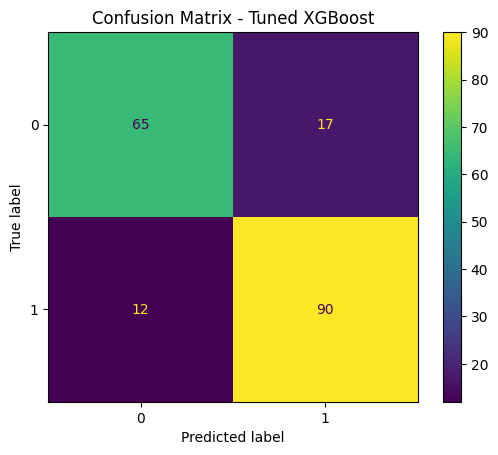

In [96]:
import matplotlib.pyplot as plt
from sklearn.metrics import ConfusionMatrixDisplay

ConfusionMatrixDisplay.from_predictions(y_test, y_pred)

plt.title("Confusion Matrix - Tuned XGBoost")
plt.show()

In [97]:
from xgboost import XGBClassifier
from sklearn.pipeline import Pipeline

baseline_model = Pipeline([
    ("preprocessor", preprocessor),
    ("model", XGBClassifier(
        random_state=42,
        eval_metric="logloss"
    ))
])

In [98]:
baseline_model.fit(X_train, y_train)

,steps,"[('preprocessor', ...), ('model', ...)]"
,transform_input,None
,memory,None
,verbose,False
,transformers,"[('cat', ...), ('num', ...)]"
,remainder,'drop'
,sparse_threshold,0.3
,n_jobs,None
,transformer_weights,None
,verbose,False
,verbose_feature_names_out,True


In [99]:
baseline_proba = baseline_model.predict_proba(X_test)[:, 1]
baseline_pred = baseline_model.predict(X_test)

In [100]:
from sklearn.metrics import roc_auc_score

baseline_auc = roc_auc_score(y_test, baseline_proba)

print("Baseline ROC-AUC:", baseline_auc)

Baseline ROC-AUC: 0.8870157819225252


In [101]:
best_model = random_search.best_estimator_

In [102]:
tuned_proba = best_model.predict_proba(X_test)[:, 1]

tuned_auc = roc_auc_score(y_test, tuned_proba)

print("Baseline ROC-AUC:", baseline_auc)
print("Tuned ROC-AUC:", tuned_auc)

Baseline ROC-AUC: 0.8870157819225252
Tuned ROC-AUC: 0.9252749880439981


In [103]:
from sklearn.metrics import classification_report, confusion_matrix

tuned_pred = best_model.predict(X_test)

print(classification_report(y_test, tuned_pred))
print("Confusion Matrix:")
print(confusion_matrix(y_test, tuned_pred))

              precision    recall  f1-score   support

           0       0.84      0.79      0.82        82
           1       0.84      0.88      0.86       102

    accuracy                           0.84       184
   macro avg       0.84      0.84      0.84       184
weighted avg       0.84      0.84      0.84       184

Confusion Matrix:
[[65 17]
 [12 90]]


In [104]:
tuned_proba = best_model.predict_proba(X_test)[:, 1]

In [ ]:
tuned_proba

In [105]:
import numpy as np
from sklearn.metrics import precision_score, recall_score, f1_score

thresholds = np.arange(0.1, 0.91, 0.05)

results = []

for threshold in thresholds:
    y_pred_threshold = (tuned_proba >= threshold).astype(int)

    precision = precision_score(y_test, y_pred_threshold)
    recall = recall_score(y_test, y_pred_threshold)
    f1 = f1_score(y_test, y_pred_threshold)

    results.append({
        "threshold": threshold,
        "precision": precision,
        "recall": recall,
        "f1": f1
    })

results_df = pd.DataFrame(results)

print(results_df)

    threshold  precision    recall        f1
0        0.10   0.666667  1.000000  0.800000
1        0.15   0.718310  1.000000  0.836066
2        0.20   0.737226  0.990196  0.845188
3        0.25   0.765152  0.990196  0.863248
4        0.30   0.787402  0.980392  0.873362
5        0.35   0.803279  0.960784  0.875000
6        0.40   0.801653  0.950980  0.869955
7        0.45   0.815789  0.911765  0.861111
8        0.50   0.841121  0.882353  0.861244
9        0.55   0.865385  0.882353  0.873786
10       0.60   0.895833  0.843137  0.868687
11       0.65   0.913978  0.833333  0.871795
12       0.70   0.905882  0.754902  0.823529
13       0.75   0.913580  0.725490  0.808743
14       0.80   0.929577  0.647059  0.763006
15       0.85   0.923077  0.588235  0.718563
16       0.90   0.956522  0.431373  0.594595


In [106]:
tuned_proba = best_model.predict_proba(X_test)[:, 1]

In [107]:
import numpy as np
import pandas as pd
from sklearn.metrics import precision_score, recall_score, f1_score

thresholds = np.arange(0.10, 0.91, 0.05)

results = []

for threshold in thresholds:
    y_pred_threshold = (tuned_proba >= threshold).astype(int)

    precision = precision_score(y_test, y_pred_threshold)
    recall = recall_score(y_test, y_pred_threshold)
    f1 = f1_score(y_test, y_pred_threshold)

    results.append({
        "threshold": round(threshold, 2),
        "precision": round(precision, 3),
        "recall": round(recall, 3),
        "f1": round(f1, 3)
    })

results_df = pd.DataFrame(results)

print(results_df)

    threshold  precision  recall     f1
0        0.10      0.667   1.000  0.800
1        0.15      0.718   1.000  0.836
2        0.20      0.737   0.990  0.845
3        0.25      0.765   0.990  0.863
4        0.30      0.787   0.980  0.873
5        0.35      0.803   0.961  0.875
6        0.40      0.802   0.951  0.870
7        0.45      0.816   0.912  0.861
8        0.50      0.841   0.882  0.861
9        0.55      0.865   0.882  0.874
10       0.60      0.896   0.843  0.869
11       0.65      0.914   0.833  0.872
12       0.70      0.906   0.755  0.824
13       0.75      0.914   0.725  0.809
14       0.80      0.930   0.647  0.763
15       0.85      0.923   0.588  0.719
16       0.90      0.957   0.431  0.595


In [108]:
FP_COST = 100
FN_COST = 1000

In [109]:
from sklearn.metrics import confusion_matrix

cost_results = []

for threshold in thresholds:

    y_pred_threshold = (tuned_proba >= threshold).astype(int)

    tn, fp, fn, tp = confusion_matrix(
        y_test,
        y_pred_threshold
    ).ravel()

    total_cost = (fp * FP_COST) + (fn * FN_COST)

    cost_results.append({
        "threshold": round(threshold, 2),
        "FP": fp,
        "FN": fn,
        "total_cost": total_cost
    })

cost_df = pd.DataFrame(cost_results)

print(cost_df)

    threshold  FP  FN  total_cost
0        0.10  51   0        5100
1        0.15  40   0        4000
2        0.20  36   1        4600
3        0.25  31   1        4100
4        0.30  27   2        4700
5        0.35  24   4        6400
6        0.40  24   5        7400
7        0.45  21   9       11100
8        0.50  17  12       13700
9        0.55  14  12       13400
10       0.60  10  16       17000
11       0.65   8  17       17800
12       0.70   8  25       25800
13       0.75   7  28       28700
14       0.80   5  36       36500
15       0.85   5  42       42500
16       0.90   2  58       58200


In [110]:
best_threshold = cost_df.loc[
    cost_df["total_cost"].idxmin(),
    "threshold"
]

print("Best threshold:", best_threshold)

Best threshold: 0.15


In [111]:
model.predict(X_test)

array([0, 1, 1, 1, 1, 1, 0, 1, 0, 1, 0, 0, 0, 0, 1, 1, 0, 1, 0, 1, 1, 1,
       0, 0, 1, 1, 0, 1, 0, 0, 0, 0, 0, 1, 1, 1, 1, 1, 0, 0, 1, 1, 1, 0,
       1, 1, 1, 1, 1, 1, 0, 0, 0, 0, 1, 0, 1, 0, 0, 0, 0, 1, 0, 1, 0, 1,
       1, 1, 0, 0, 1, 1, 0, 1, 0, 1, 1, 0, 1, 1, 0, 1, 1, 0, 1, 0, 1, 1,
       0, 1, 0, 1, 0, 0, 0, 1, 1, 1, 1, 1, 1, 1, 1, 0, 1, 1, 1, 1, 0, 1,
       1, 0, 0, 1, 1, 1, 1, 0, 0, 1, 0, 1, 0, 1, 0, 1, 0, 1, 1, 0, 0, 1,
       0, 0, 1, 1, 0, 0, 1, 1, 1, 1, 0, 0, 1, 1, 1, 0, 0, 1, 1, 0, 1, 1,
       1, 1, 0, 1, 1, 0, 0, 1, 1, 0, 1, 1, 1, 1, 0, 1, 1, 0, 1, 1, 0, 0,
       0, 0, 1, 1, 1, 1, 1, 1])

In [112]:
best_threshold = 0.15

y_pred_cost = (tuned_proba >= best_threshold).astype(int)

from sklearn.metrics import (
    classification_report,
    confusion_matrix,
    roc_auc_score
)

print("Threshold:", best_threshold)

print("\nClassification Report:")
print(classification_report(y_test, y_pred_cost))

print("\nConfusion Matrix:")
print(confusion_matrix(y_test, y_pred_cost))

Threshold: 0.15

Classification Report:
              precision    recall  f1-score   support

           0       1.00      0.51      0.68        82
           1       0.72      1.00      0.84       102

    accuracy                           0.78       184
   macro avg       0.86      0.76      0.76       184
weighted avg       0.84      0.78      0.77       184


Confusion Matrix:
[[ 42  40]
 [  0 102]]


In [113]:
tn, fp, fn, tp = confusion_matrix(
    y_test,
    y_pred_cost
).ravel()

FP_COST = 100
FN_COST = 1000

total_cost = (fp * FP_COST) + (fn * FN_COST)

print("TN:", tn)
print("FP:", fp)
print("FN:", fn)
print("TP:", tp)
print("Total business cost:", total_cost)

TN: 42
FP: 40
FN: 0
TP: 102
Total business cost: 4000


In [114]:
# Interpreat 

xgb_model = best_model.named_steps["model"]

In [115]:
preprocessor_fitted = best_model.named_steps["preprocessor"]

In [116]:
feature_names = preprocessor_fitted.get_feature_names_out()

In [ ]:
print(feature_names)

In [118]:
importance = xgb_model.feature_importances_

In [119]:
feature_importance_df = pd.DataFrame({
    "feature": feature_names,
    "importance": importance})

In [ ]:
feature_importance_df = feature_importance_df.sort_values(
    by="importance",
    ascending=False
)

In [120]:
print(feature_importance_df.head(15))

                        feature  importance
0               cat__sex_Female    0.034119
1                 cat__sex_Male    0.000000
2        cat__dataset_Cleveland    0.001087
3          cat__dataset_Hungary    0.017489
4      cat__dataset_Switzerland    0.033302
5    cat__dataset_VA Long Beach    0.072818
6          cat__cp_asymptomatic    0.229831
7       cat__cp_atypical angina    0.038408
8           cat__cp_non-anginal    0.002176
9        cat__cp_typical angina    0.000000
10               cat__fbs_False    0.020117
11                cat__fbs_True    0.017336
12                 cat__fbs_nan    0.000000
13  cat__restecg_lv hypertrophy    0.024579
14          cat__restecg_normal    0.011253


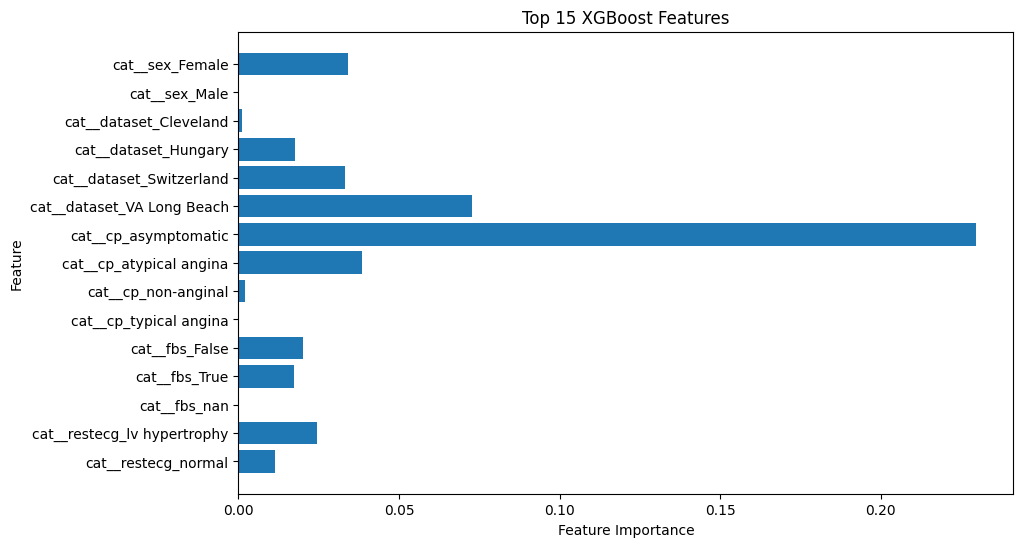

In [122]:
import matplotlib.pyplot as plt

top_features = feature_importance_df.head(15)

plt.figure(figsize=(10, 6))

plt.barh(
    top_features["feature"],
    top_features["importance"]
)

plt.gca().invert_yaxis()

plt.xlabel("Feature Importance")
plt.ylabel("Feature")
plt.title("Top 15 XGBoost Features")

plt.show()

In [123]:
import numpy as np
import shap
import numba

In [124]:
explainer = shap.TreeExplainer(xgb_model)

In [125]:
X_test_transformed = preprocessor_fitted.transform(X_test)

In [126]:
shap_values = explainer.shap_values(X_test_transformed)

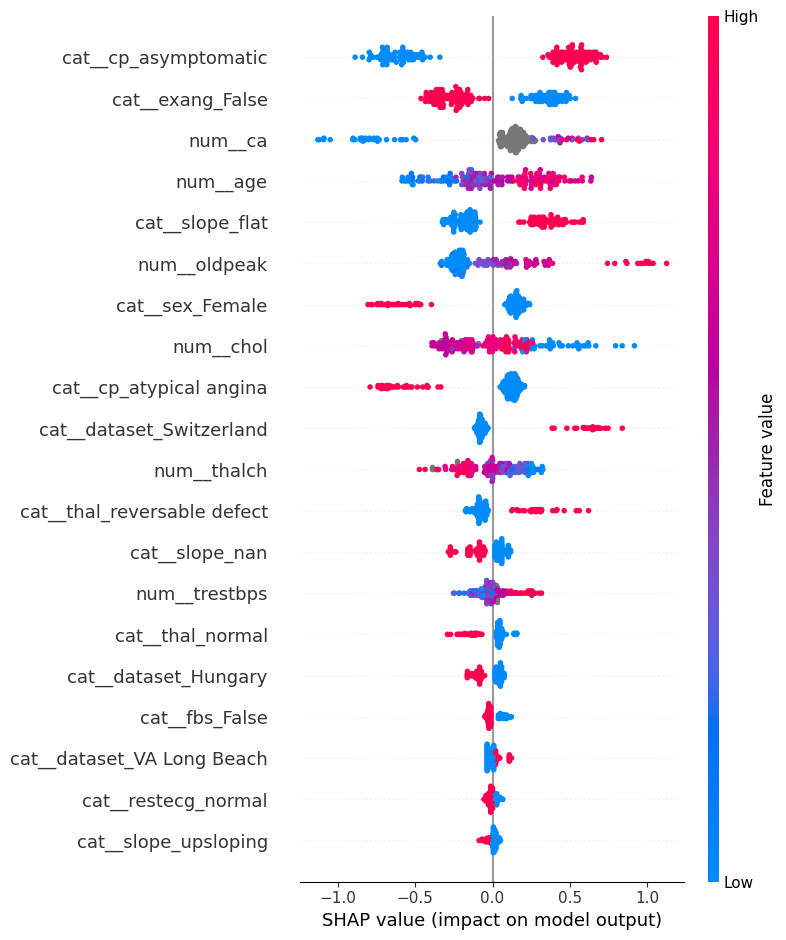

In [127]:
shap.summary_plot(
    shap_values,
    X_test_transformed,
    feature_names=feature_names
)

In [128]:
sample_index = 0

X_sample = X_test_transformed[sample_index:sample_index+1]

sample_shap = shap_values[sample_index]

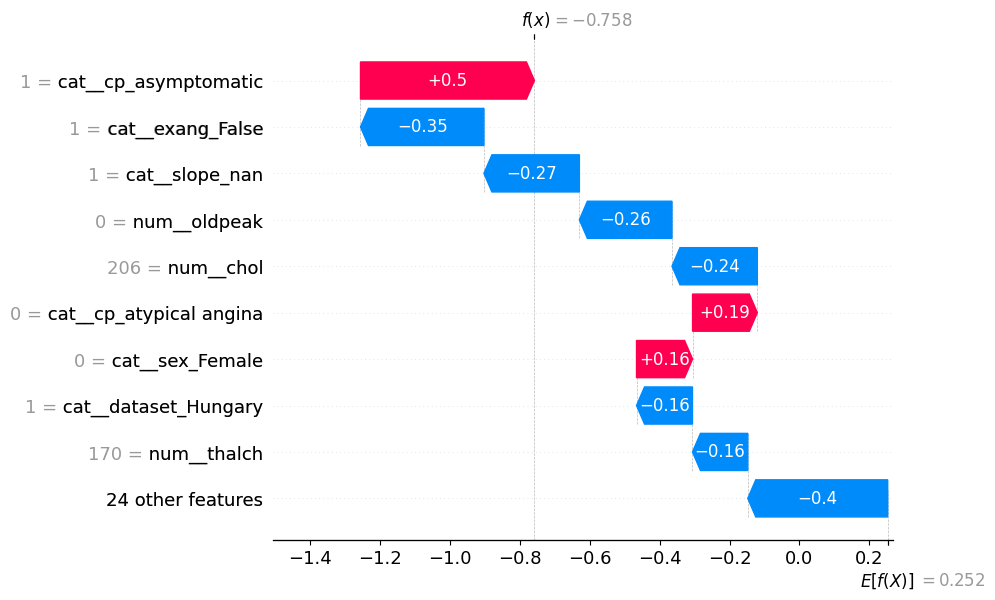

In [129]:
shap.plots.waterfall(
    shap.Explanation(
        values=sample_shap,
        base_values=explainer.expected_value,
        data=X_sample.toarray()[0] if hasattr(X_sample, "toarray") else X_sample[0],
        feature_names=feature_names
    )
)

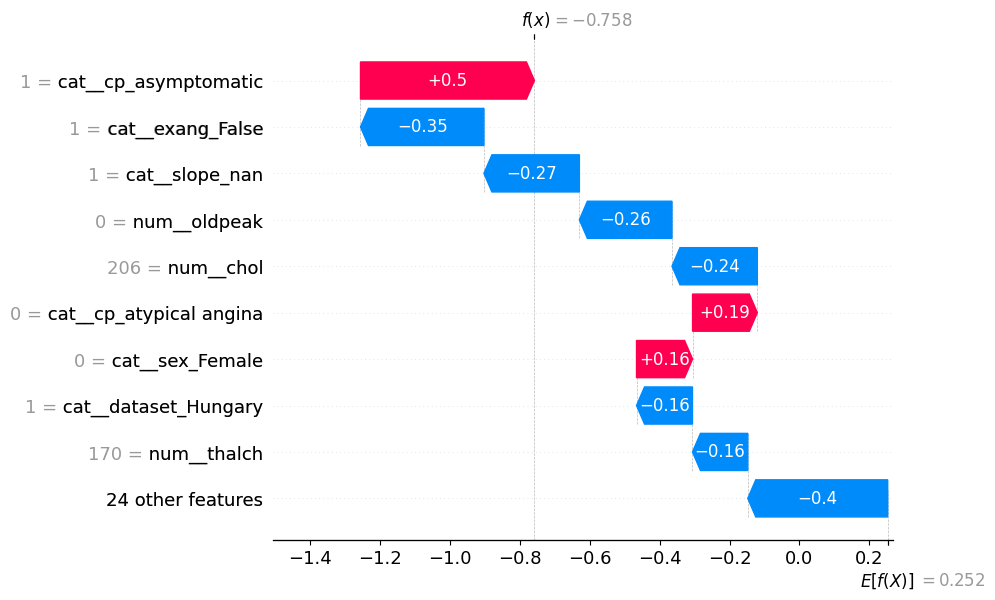

In [130]:
sample_index = 0

X_sample = X_test_transformed[sample_index:sample_index+1]
sample_shap = shap_values[sample_index]

shap.plots.waterfall(
    shap.Explanation(
        values=sample_shap,
        base_values=explainer.expected_value,
        data=X_sample.toarray()[0] if hasattr(X_sample, "toarray") else X_sample[0],
        feature_names=feature_names
    )
)

In [131]:
import joblib

joblib.dump(best_model, "heart_disease_xgb_pipeline.pkl")

['heart_disease_xgb_pipeline.pkl']

In [132]:
import os

print(os.path.exists("heart_disease_xgb_pipeline.pkl"))

True


In [133]:
loaded_model = joblib.load("heart_disease_xgb_pipeline.pkl")

In [134]:
predictions = loaded_model.predict(X_test)

print(predictions[:10])

[0 1 1 1 1 1 0 1 0 1]


In [135]:
probabilities = loaded_model.predict_proba(X_test)[:, 1]

print(probabilities[:10])

[0.31905326 0.9668384  0.7386178  0.9503356  0.5972807  0.72728604
 0.2145302  0.92200094 0.09129359 0.86277163]


In [136]:
original_pred = best_model.predict(X_test)
loaded_pred = loaded_model.predict(X_test)

print((original_pred == loaded_pred).all())

True


In [137]:
original_proba = best_model.predict_proba(X_test)[:, 1]
loaded_proba = loaded_model.predict_proba(X_test)[:, 1]

print((original_proba == loaded_proba).all())

True


In [138]:
threshold = 0.15

model_artifact = {
    "model": best_model,
    "threshold": threshold
}

joblib.dump(model_artifact, "heart_disease_model.pkl")

['heart_disease_model.pkl']

In [139]:
artifact = joblib.load("heart_disease_model.pkl")

model = artifact["model"]
threshold = artifact["threshold"]

print(threshold)

0.15


In [140]:
probability = model.predict_proba(X_test)[:, 1]

prediction = (probability >= threshold).astype(int)

print(prediction[:10])

[1 1 1 1 1 1 1 1 0 1]


In [141]:
import joblib
import pandas as pd

# Load saved model
artifact = joblib.load("heart_disease_model.pkl")

model = artifact["model"]
threshold = artifact["threshold"]

In [142]:
def predict_heart_disease(patient_data):

    # Convert input into DataFrame
    patient_df = pd.DataFrame([patient_data])

    # Get probability
    probability = model.predict_proba(patient_df)[0, 1]

    # Apply business threshold
    prediction = int(probability >= threshold)

    return {
        "probability": probability,
        "prediction": prediction
    }

In [143]:
patient = {
    "age": 55,
    "sex": "Male",
    "dataset": "Cleveland",
    "cp": "typical angina",
    "trestbps": 140,
    "chol": 250,
    "fbs": False,
    "restecg": "normal",
    "thalch": 150,
    "exang": False,
    "oldpeak": 1.5,
    "slope": "upsloping",
    "ca": 0,
    "thal": "normal"
}

In [144]:
result = predict_heart_disease(patient)

print(result)

{'probability': np.float32(0.12834802), 'prediction': 0}


In [145]:
# imporving function 

def predict_heart_disease(patient_data):

    patient_df = pd.DataFrame([patient_data])

    probability = model.predict_proba(patient_df)[0, 1]

    prediction = int(probability >= threshold)

    if prediction == 1:
        result = "Class 1"
    else:
        result = "Class 0"

    return {
        "prediction": result,
        "probability": round(float(probability), 4),
        "threshold": threshold
    }

In [146]:
result = predict_heart_disease(patient)

print(result)

{'prediction': 'Class 0', 'probability': 0.1283, 'threshold': 0.15}


In [147]:
%pip install fastapi uvicorn

Defaulting to user installation because normal site-packages is not writeable
Looking in links: /usr/share/pip-wheels
Note: you may need to restart the kernel to use updated packages.


In [149]:
import joblib
import pandas as pd
from fastapi import FastAPI

# Load model
artifact = joblib.load("heart_disease_model.pkl")

model = artifact["model"]
threshold = artifact["threshold"]

# Create API
app = FastAPI(title="Heart Disease Prediction API")


@app.get("/")
def home():
    return {
        "message": "Heart Disease Prediction API is running"
    }


@app.post("/predict")
def predict(patient_data: dict):

    patient_df = pd.DataFrame([patient_data])

    probability = model.predict_proba(patient_df)[0, 1]

    prediction = int(probability >= threshold)

    return {
        "prediction": prediction,
        "probability": round(float(probability), 4),
        "threshold": threshold
    }

In [152]:
import os

print(os.getcwd())
print(os.listdir())

/home/c2d7bc1b-d73a-414e-bd72-b357fd4620b7/pandas.ipynb
['NLP3 - Text Preprocessing core+adv.ipynb', 'Untitled.ipynb', 'Untitled1.ipynb', '.ipynb_checkpoints', 'NLP - Part of Speech and NER.ipynb', 'heart_disease_xgb_pipeline.pkl', 'IMDB_Dataset.csv', 'heart_disease_uci.csv', 'Sentiment_analysis.ipynb', 'Bag-of-Words in NLP.pptx', 'NLP Mini Project - SMS SPAM.ipynb', 'POS1.ipynb', 'Untitled3.ipynb', 'heart_disease_model.pkl', 'Untitled Folder', 'NLP Chunking.ipynb', 'Untitled2.ipynb', 'Learning POS Tagging & Chunking in NLP.pptx']


In [158]:
%%writefile app.py

import joblib
import pandas as pd
from fastapi import FastAPI

# Load saved model
artifact = joblib.load("heart_disease_model.pkl")

model = artifact["model"]
threshold = artifact["threshold"]

# Create FastAPI application
app = FastAPI(title="Heart Disease Prediction API")


@app.get("/")
def home():
    return {
        "message": "Heart Disease Prediction API is running"
    }


@app.post("/predict")
def predict(patient_data: dict):

    patient_df = pd.DataFrame([patient_data])

    probability = model.predict_proba(patient_df)[0, 1]

    prediction = int(probability >= threshold)

    return {
        "prediction": prediction,
        "probability": round(float(probability), 4),
        "threshold": threshold
    }

Writing app.py


In [159]:
import os

print(os.path.exists("app.py"))

True


In [ ]:
import sys

!{sys.executable} -m uvicorn app:app --port 8080

/home/c2d7bc1b-d73a-414e-bd72-b357fd4620b7/.local/lib/python3.12/site-packages/xgboost/compat.py:105: UserWarning: pkg_resources is deprecated as an API. See https://setuptools.pypa.io/en/latest/pkg_resources.html. The pkg_resources package is slated for removal as early as 2025-11-30. Refrain from using this package or pin to Setuptools<81.
  import pkg_resources
INFO:     Started server process [1189]
INFO:     Waiting for application startup.
INFO:     Application startup complete.
INFO:     Uvicorn running on http://127.0.0.1:8080 (Press CTRL+C to quit)
INFO:     127.0.0.1:35572 - "GET /docs HTTP/1.1" 200 OK


In [ ]:
import os

for key in os.environ:
    if "JUPYTER" in key.upper():
        print(key, "=", os.environ[key])

In [ ]:
import requests

r = requests.get("http://127.0.0.1:8080/docs")
print(r.status_code)
print(r.url)